In [1]:
import numpy as np
import sys,os
import MAS_library as MASL
import pickle as pk
import h5py as h5
import matplotlib
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
pl.rc('font', family='DejaVu Sans')
%matplotlib inline



In [2]:
with open('test_newcode.pk', 'rb') as f:
    saved = pk.load(f)
    story_full = saved['story_full']
    prop_truth_all = saved['prop_truth_all']
    pos_h_truth = saved['pos_h_truth']
    vel_h_truth = saved['vel_h_truth']
    Nhalos_truth_rs = saved['Nhalos_truth_rs']



In [3]:
prop_truth_all.shape, pos_h_truth.shape, vel_h_truth.shape


((523, 5), (523, 3), (523,))

In [4]:
nrand_sel_box = 128
norm_delta = 500
norm_vel = 500
BoxSize = 25.
grid = 8
# grid_sbox = 32
grid_sbox = 64
nvocab = 64
MAS_type = 'NGP'
grid_tot = grid_sbox * grid
prop_min = np.array([7.5, 26, 26, 26, -0.75])
prop_max = np.array([11.5, 30, 30, 30, 0.75])
Npoints_max_per_subvol = 25
nMax_points = 4
#sort by Mstar token:
ind_token_to_sort = 3
add_space_token = False

dim_pos = 3
dim_prop = 5
dim_tot = dim_pos + dim_prop

start_token = nvocab + 1
space_token = nvocab + 2
pad_token = nvocab + 3
end_token = nvocab + 4


if add_space_token:
    max_sentence_length = 1 + Npoints_max_per_subvol*dim_tot + 1 + (Npoints_max_per_subvol - 1)
else:
    max_sentence_length = 1 + Npoints_max_per_subvol*dim_tot + 1


bins_digitize = np.linspace(-1e-3, 1, nvocab)
bins_digitize = np.insert(bins_digitize, 0, -1)
delta_bin = bins_digitize[5] - bins_digitize[4]

prop_min = np.array([7.5, 26, 26, 26, -0.75])
prop_max = np.array([11.5, 30, 30, 30, 0.75])
xall = (np.linspace(0, BoxSize/grid, grid_sbox + 1))
xarray = 0.5 * (xall[1:] + xall[:-1])
yarray = np.copy(xarray)
zarray = np.copy(xarray)


In [5]:
sentences_all = story_full.reshape((grid, grid, grid, max_sentence_length))




In [39]:
pos_infer_all = []
prop_infer_all = []

# jx, jy, jz = 0, 5, 2
# jx, jy, jz = 0, 5, 0
for jx in range(grid):
    for jy in range(grid):
        for jz in range(grid):
            Nhalos_truth = int(np.sum(Nhalos_truth_rs[jx, jy, jz]))
            sentence_here = sentences_all[jx, jy, jz]
            if add_space_token:
                ntokens_per_halo = dim_tot + 1
            else:
                ntokens_per_halo = dim_tot
            ind_start_token = np.where(sentence_here == start_token)[0]
            if end_token in sentence_here:
                ind_end_token = np.where(sentence_here == end_token)[0]
                Nhalos_here = ((ind_end_token - ind_start_token - 1) / ntokens_per_halo)[0]
                if (int(Nhalos_here) - Nhalos_here) != 0:
                    print('Nhalos_here is not an integer')
                else:
                    # print('Nhalos_here = ', Nhalos_here, 'Nhalos_truth = ', Nhalos_truth)
                    if Nhalos_here > 0:
                        for jh in range(int(Nhalos_here)):
                            coord_x = xarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 1]] + (BoxSize/grid)*jx
                            coord_y = yarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 2]] + (BoxSize/grid)*jy
                            coord_z = zarray[sentence_here[ind_start_token + jh*ntokens_per_halo + 3]] + (BoxSize/grid)*jz
                            pos_infer_all.append([coord_x, coord_y, coord_z])
                            prop_all = np.zeros(dim_prop)
                            for jp in range(dim_prop):
                                noise_val = np.random.uniform(-delta_bin, delta_bin)
                                bin_val_jp = sentence_here[ind_start_token + jh*ntokens_per_halo + 4 + jp]
                                prop_all[jp] = prop_min[jp] + (prop_max[jp] - prop_min[jp]) * (bins_digitize[bin_val_jp] + noise_val)
                            prop_infer_all.append(prop_all)
            else:           
                print('End token not found')

pos_infer_all = np.array(pos_infer_all)[:,:,0]
prop_infer_all = np.array(prop_infer_all)


/tmp/ipykernel_2673669/1299400707.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prop_all[jp] = prop_min[jp] + (prop_max[jp] - prop_min[jp]) * (bins_digitize[bin_val_jp] + noise_val)


In [40]:
# np.random.uniform(-delta_bin, delta_bin)
# delta_bin
prop_all

array([ 7.99152637, 26.94990278, 27.15975141, 27.23531248,  0.17038337])

In [41]:
# np.array(pos_infer_all).shape, np.array(prop_infer_all).shape


# jh = 1
# jc = 0
# ind_start_token + jh*ntokens_per_halo + jc + 1
# prop_min[jp] + (prop_max[jp] - prop_min[jp]) * bins_digitize[sentence_here[ind_start_token + jh*ntokens_per_halo + 4 + jp]]


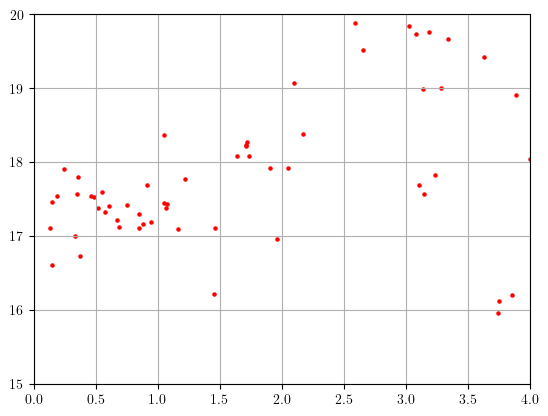

In [44]:
pl.figure()
pl.scatter(pos_h_truth[:, 0], pos_h_truth[:, 1], c='r', s=5)
pl.xlim(0,4)
pl.ylim(15, 20)
pl.grid()


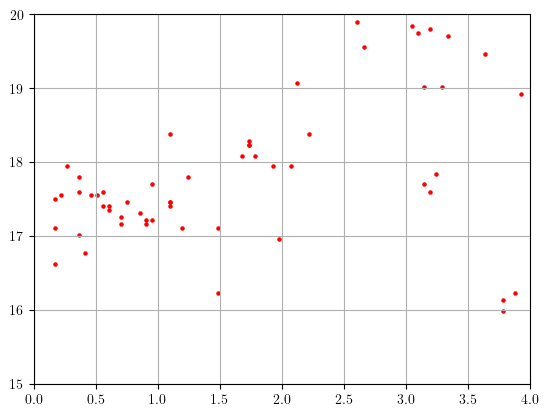

In [45]:
pl.figure()
pl.scatter(pos_infer_all[:, 0], pos_infer_all[:, 1], c='r', s=5)
pl.xlim(0,4)
pl.ylim(15, 20)
pl.grid()



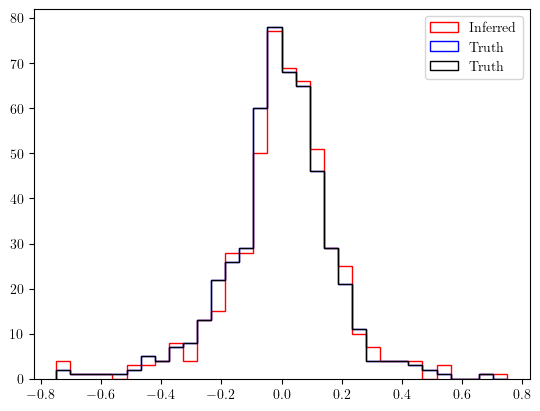

In [27]:
jp = -1
pl.figure()
_ = pl.hist(prop_infer_all[:, jp], bins=32, range=(prop_min[jp], prop_max[jp]), histtype='step', color='r', label='Inferred')
_ = pl.hist(prop_truth_all[:, jp], bins=32, range=(prop_min[jp], prop_max[jp]), histtype='step', color='b', label='Truth')
_ = pl.hist(vel_h_truth, bins=32, range=(prop_min[jp], prop_max[jp]), histtype='step', color='k', label='Truth')
pl.legend()



In [11]:
import Pk_library as PKL
import MAS_library as MASL


In [56]:
isim_fid = 0

threads = 16

ind_prop = 0
normw = 10**8
params_all = np.loadtxt('/projects/bdne/spandey3/GOTHAM/prep_data/camels_tng_LH_params.txt', usecols=range(1, 7))
z = 0.0
BoxSize = 25

grid_Pk = 256
MAS = 'TSC'
Om = params_all[isim_fid, 0]
Hz = 100.0 * np.sqrt(Om * (1. + z)**3 + (1 - Om))
rsd_factor = (1. + z) / Hz

pos_truth = pos_h_truth
# vel_truth = vel_h_truth

# pos_truth = (pos_truth + (vel_truth * rsd_factor)[:,None])%(BoxSize)
# pos_truth[:,0] = (pos_truth[:,0] + (vel_truth * rsd_factor))%(BoxSize)
mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
MASL.MA(pos_truth.astype(np.float32), mesh_truth, BoxSize, MAS)

# W = (10**prop_truth_all[:,ind_prop].astype(np.float32))/normw
# MASL.MA(pos_truth.astype(np.float32), mesh_truth, BoxSize, MAS , W=W) 

mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
Pk_truth = PKL.Pk(mesh_truth, BoxSize, axis=0, MAS=None, threads=threads, verbose=False)
# Pk_truth_all.append(Pk_truth.Pk[:,0])
# Pk_truth_all.append(Pk_truth.Pk)

pos_pred = pos_infer_all
# vel_pred = prop_infer_all[:,-1] * 1000.
# pos_pred = (pos_pred + (vel_pred * rsd_factor)[:,None])%(BoxSize)
# pos_pred[:,0] = (pos_pred[:,0] + (vel_pred * rsd_factor))%(BoxSize)
mesh_pred = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
MASL.MA(pos_pred.astype(np.float32), mesh_pred, BoxSize, MAS)

# W = 10**prop_infer_all[:,ind_prop].astype(np.float32)/normw
# MASL.MA(pos_pred.astype(np.float32), mesh_pred, BoxSize, MAS, W=W)     

mesh_pred /= np.mean(mesh_pred, dtype=np.float64);  mesh_pred -= 1.0
Pk_pred = PKL.Pk(mesh_pred, BoxSize, axis=0, MAS=None, threads=threads, verbose=False)




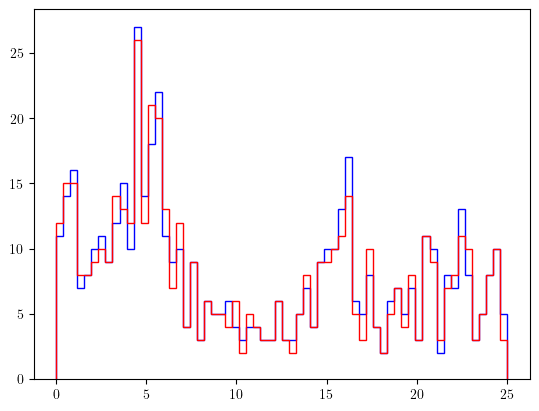

In [57]:
pl.figure()
_ = pl.hist(pos_h_truth[:,0], bins=64, range=(0, BoxSize), histtype='step', color='b', label='Truth')
_ = pl.hist(pos_infer_all[:,0], bins=64, range=(0, BoxSize), histtype='step', color='r', label='Inferred')


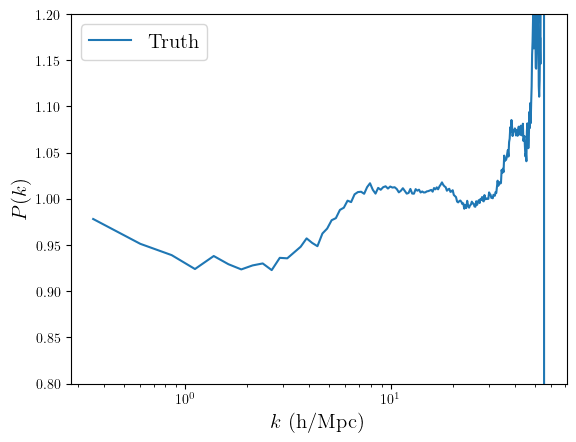

In [59]:
pl.figure()
pl.plot(Pk_truth.k3D, Pk_pred.Pk[:,0]/Pk_truth.Pk[:,0], label='Truth')
# pl.plot(Pk_pred.k3D, Pk_pred.Pk[:,0], label='Inferred')
pl.xlabel(r'$k$ (h/Mpc)', fontsize=15)
pl.ylabel(r'$P(k)$', fontsize=15)
pl.ylim(0.8, 1.2)
# pl.yscale('log')
pl.xscale('log')
pl.legend(fontsize=15)




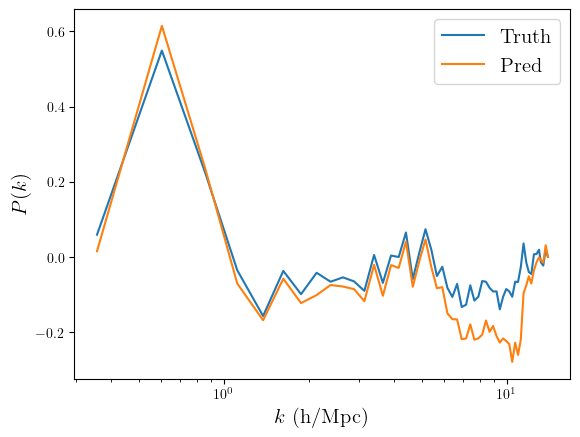

In [107]:
pl.figure()
pl.plot(Pk_truth.k3D, Pk_truth.Pk[:,1]/Pk_truth.Pk[:,0], label='Truth')
pl.plot(Pk_truth.k3D, Pk_pred.Pk[:,1]/Pk_pred.Pk[:,0], label='Pred')
# pl.plot(Pk_pred.k3D, Pk_pred.Pk[:,0], label='Inferred')
pl.xlabel(r'$k$ (h/Mpc)', fontsize=15)
pl.ylabel(r'$P(k)$', fontsize=15)
# pl.ylim(0.8, 1.2)
pl.xscale('log')
pl.legend(fontsize=15)




In [ ]:
# Go from sentence to the original simulation:
sentences_all = story_full.reshape((grid, grid, grid, max_sentence_length))
for jx in range(grid):
    for jy in range(grid):
        for jz in range(grid):
            Nhalos_truth = np.sum(Nhalos_truth_rs[jx, jy, jz])
            sentence_here = sentences_all[jx, jy, jz]
            if add_space_token:
                ntokens_per_halo = dim_tot + 1
            else:
                ntokens_per_halo = dim_tot
            ind_start_token = np.where(sentence_here == start_token)[0]
            if end_token in sentence_here:
                ind_end_token = np.where(sentence_here == end_token)[0]
                Nhalos_here = (ind_end_token - ind_start_token) // ntokens_per_halo
                print('Nhalos_here = ', Nhalos_here)
            else:
                print('End token not found')
            